In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('melb_data.csv')
print(df.shape)

(13580, 21)


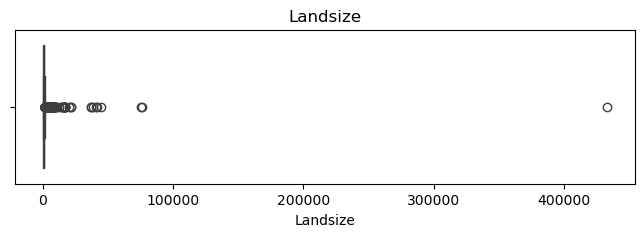

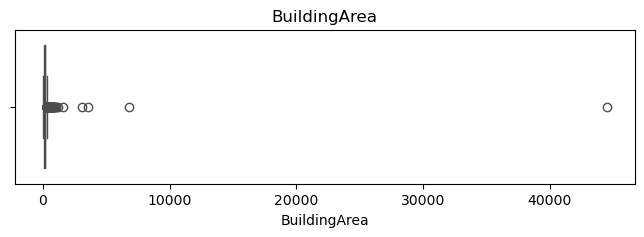

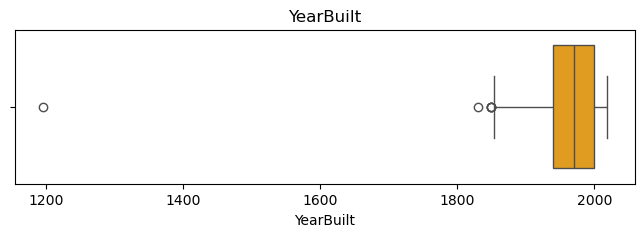

In [183]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='Landsize')
plt.title('Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='BuildingArea', color='orange')
plt.title('BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data = df, x='YearBuilt', color='orange')
plt.title('YearBuilt')
plt.show()

In [184]:
# missing values per column
missing_counts = df.isnull().sum()

# precentage of missing values
missing_percentages = (df.isnull().sum() / len(df)) * 100

# Table of missing count and percentage
missing_summary = pd.DataFrame(
    {'Missing Count': missing_counts,
    'Percentage (%)': missing_percentages})

# shows the varibles that has missing values in decending order
final_report = missing_summary[missing_summary['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print(final_report)

              Missing Count  Percentage (%)
BuildingArea           6450       47.496318
YearBuilt              5375       39.580265
CouncilArea            1369       10.081001
Car                      62        0.456554


In [185]:
# Assume missing car spaces mean 0 parking spots available
df['Car'] = df['Car'].fillna(0)

# checks if there is still missing values
car = df['Car'].count()
print(car)

13580


In [186]:
# Drops rows where BuildingArea and YearBuilt are missing
df_clean = df.dropna(subset=['BuildingArea', 'YearBuilt'])

# Remove impossible 0 square metre entries
df_clean = df_clean[df_clean['Landsize'] > 0]
df_clean = df_clean[df_clean['BuildingArea'] > 0]

# Fix the Date data type mismatch so it plots chronologically
df_clean['Date'] = pd.to_datetime(df_clean['Date'], format='%d/%m/%Y', errors='coerce')

In [187]:
print("Check")
print("Number of properties with 0 Landsize left:", (df_clean['Landsize'] == 0).sum())
print("Number of properties with 0 Building area left:", (df_clean['BuildingArea'] == 0).sum())
print("Number of missing values left in Car column:", df_clean['Car'].isnull().sum())
print("Total rows remaining in cleaned dataset:", len(df_clean))

Check
Number of properties with 0 Landsize left: 0
Number of properties with 0 Building area left: 0
Number of missing values left in Car column: 0
Total rows remaining in cleaned dataset: 5826


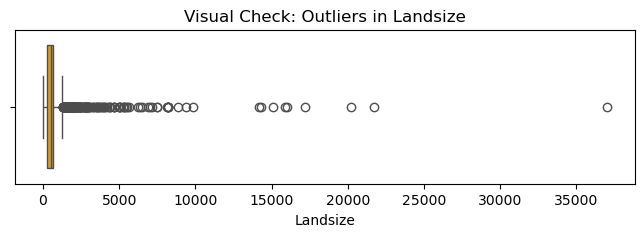

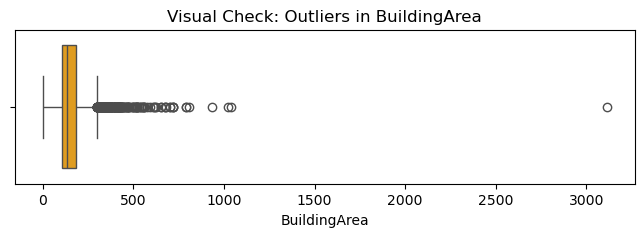

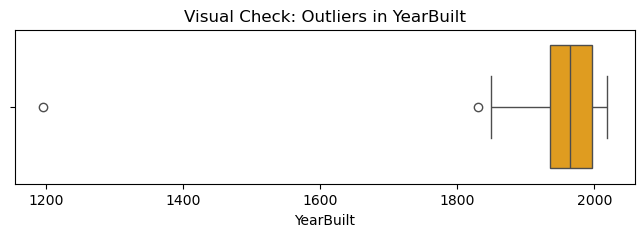

In [188]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [189]:
# 1. Reset df_clean back to a fresh copy of your raw data
df_clean = df.copy()

In [190]:
# --- Clean Landsize ---
Q1_land = df_clean['Landsize'].quantile(0.25)
Q3_land = df_clean['Landsize'].quantile(0.75)
IQR_land = Q3_land - Q1_land
lower_land = Q1_land - 1.5 * IQR_land
upper_land = Q3_land + 1.5 * IQR_land
df_clean = df_clean[(df_clean['Landsize'] >= lower_land) & (df_clean['Landsize'] <= upper_land)]

# --- Clean BuildingArea ---
Q1_build = df_clean['BuildingArea'].quantile(0.25)
Q3_build = df_clean['BuildingArea'].quantile(0.75)
IQR_build = Q3_build - Q1_build
lower_build = Q1_build - 1.5 * IQR_build
upper_build = Q3_build + 1.5 * IQR_build
df_clean = df_clean[(df_clean['BuildingArea'] >= lower_build) & (df_clean['BuildingArea'] <= upper_build)]

# --- Clean YearBuilt ---
Q1_year = df_clean['YearBuilt'].quantile(0.25)
Q3_year = df_clean['YearBuilt'].quantile(0.75)
IQR_year = Q3_year - Q1_year
lower_year = Q1_year - 1.5 * IQR_year
upper_year = Q3_year + 1.5 * IQR_year
df_clean = df_clean[(df_clean['YearBuilt'] >= lower_year) & (df_clean['YearBuilt'] <= upper_year)]

print("Data successfully cleaned! Total rows remaining:", len(df_clean))

Data successfully cleaned! Total rows remaining: 6377


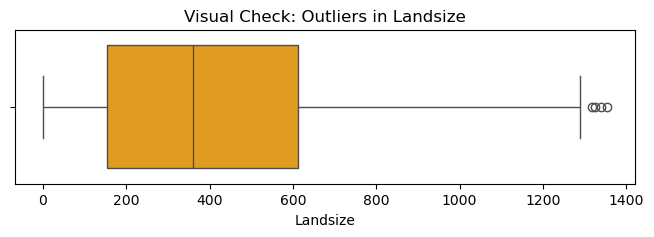

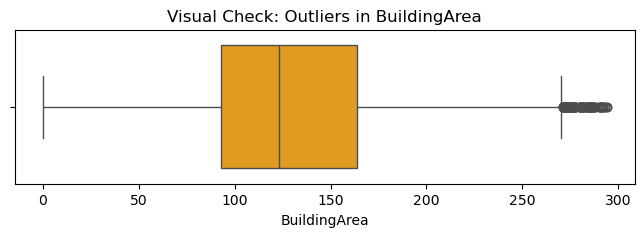

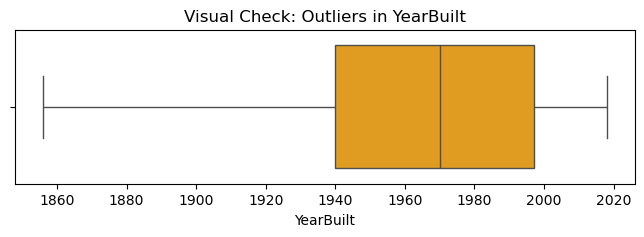

In [191]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

# Visual Check 2: BuildingArea
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [192]:
# 1. Reset df_clean back to a fresh copy of your raw data
df_clean = df.copy()

In [194]:
# 1. Remove the last remaining Landsize dots above the whisker
df_clean = df_clean[df_clean['Landsize'] <= 1280]

# 2. Remove the last remaining BuildingArea dots above the whisker
df_clean = df_clean[df_clean['BuildingArea'] <= 260]

# 3. Remove the single leftover YearBuilt dot below the whisker
df_clean = df_clean[df_clean['YearBuilt'] >= 1860]

print("Final manual trim complete! Remaining rows:", len(df_clean))


Final manual trim complete! Remaining rows: 6193


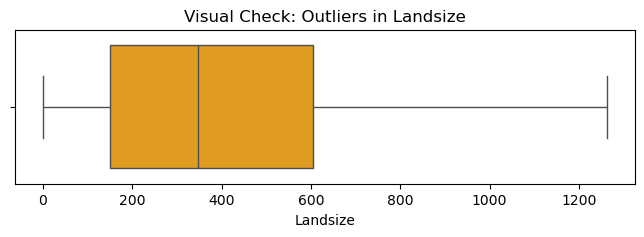

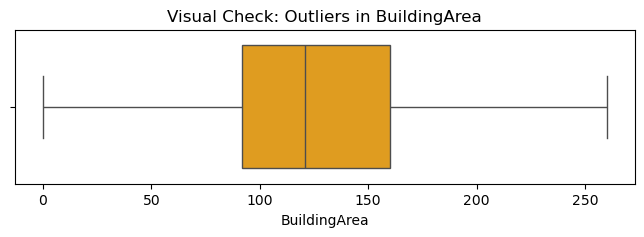

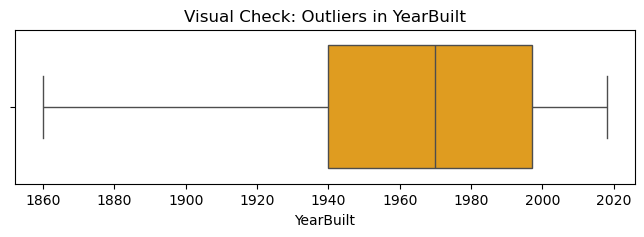

In [195]:
# Visual Check 1: Landsize
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='Landsize', color='orange')
plt.title('Visual Check: Outliers in Landsize')
plt.show()

plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='BuildingArea', color='orange')
plt.title('Visual Check: Outliers in BuildingArea')
plt.show()

# Visual Check 3: YearBuilt
plt.figure(figsize=(8, 2))
sns.boxplot(data=df_clean, x='YearBuilt', color='orange')
plt.title('Visual Check: Outliers in YearBuilt')
plt.show()

In [198]:
df_clean.to_csv('cleaned_melb_dataset', index = False)
print('data cleaned successfully!')

data cleaned successfully!
